## T01_Easy

<!-- merged from: T01_Easy.ipynb (Jupy Tools) -->

# Tutorial 1 - Easy

## Objective

To verify the successful installation of Qiskit and list the available Aer simulation backends.

In [ ]:
import qiskit
from qiskit_aer import Aer

print("Qiskit Version:", qiskit.__version__)

print("\nAvailable Backends:")

for backend in Aer.backends():
    print("-", backend.name)

Qiskit Version: 2.5.0

Available Backends:
- aer_simulator
- aer_simulator_statevector
- aer_simulator_density_matrix
- aer_simulator_stabilizer
- aer_simulator_matrix_product_state
- aer_simulator_extended_stabilizer
- aer_simulator_unitary
- aer_simulator_superop
- qasm_simulator
- statevector_simulator
- unitary_simulator


## Conclusion

The Qiskit environment is installed correctly and is ready for quantum circuit development and simulation.

## T01_Medium

<!-- merged from: T01_Medium.ipynb (Jupy Tools) -->

# Tutorial 1 - Medium

## Objective To create a one-qubit quantum circuit, apply a Hadamard gate, measure the qubit, execute the circuit with 1024 shots using the Aer simulator, and visualize the results using a histogram.

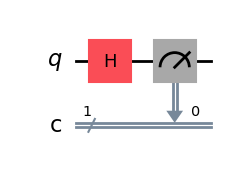

In [ ]:
from qiskit import QuantumCircuit

# Create a circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply Hadamard Gate
qc.h(0)

# Measure the qubit
qc.measure(0, 0)

# Display the circuit
qc.draw("mpl")

## Observation

The Hadamard gate placed the qubit into an equal superposition state.

After 1024 measurements, the outcomes '0' and '1' appeared with nearly equal probability.

In [ ]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# Create simulator
simulator = AerSimulator()

# Compile the circuit
compiled_circuit = transpile(qc, simulator)

# Execute the circuit
job = simulator.run(compiled_circuit, shots=1024)

# Get results
result = job.result()

# Get measurement counts
counts = result.get_counts()

print(counts)

{'0': 511, '1': 513}


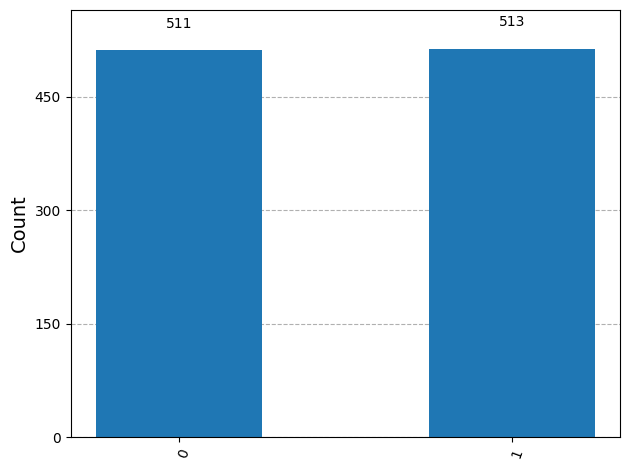

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## Conclusion

The experiment demonstrates quantum superposition using the Hadamard gate. The histogram confirms that the probabilities of measuring 0 and 1 are approximately equal.

## T01_Hard

<!-- merged from: T01_Hard.ipynb (Jupy Tools) -->

# Tutorial 1 - Hard

## Objective

To create a three-qubit quantum circuit, place all qubits into superposition using Hadamard gates, measure the qubits, execute the circuit on the Aer simulator for 1024 shots, and visualize the results using a histogram.

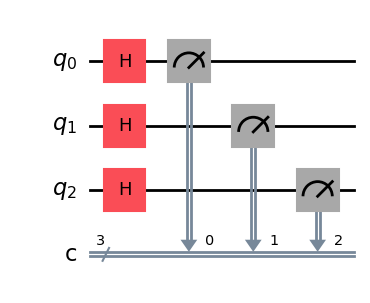

In [1]:
from qiskit import QuantumCircuit

# Create a circuit with 3 qubits and 3 classical bits
qc = QuantumCircuit(3, 3)

# Apply Hadamard gate to all qubits
qc.h([0, 1, 2])

# Measure all qubits
qc.measure([0, 1, 2], [0, 1, 2])

# Display the circuit
qc.draw("mpl")

## Observation

The Hadamard gate placed all three qubits into a superposition state.

After 1024 measurements, all eight possible binary states (000 to 111) appeared with nearly equal probability.

In [2]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# Create simulator
simulator = AerSimulator()

# Compile the circuit
compiled_circuit = transpile(qc, simulator)

# Execute the circuit
job = simulator.run(compiled_circuit, shots=1024)

# Get results
result = job.result()

# Get measurement counts
counts = result.get_counts()

print(counts)

{'101': 141, '110': 146, '011': 99, '001': 118, '010': 134, '000': 129, '100': 134, '111': 123}


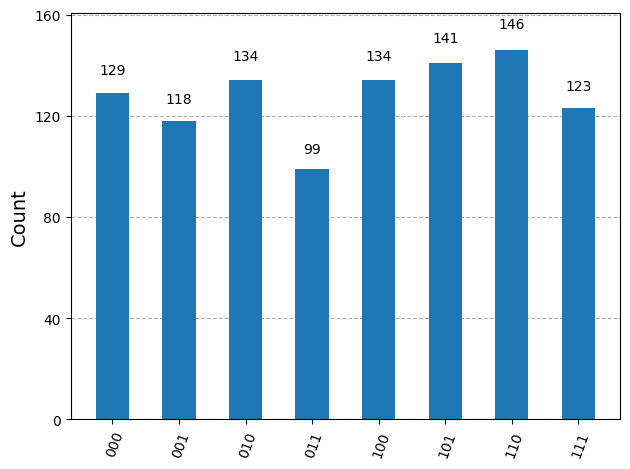

In [3]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## Conclusion

The experiment demonstrates quantum superposition on multiple qubits. Since three qubits can represent eight possible states simultaneously, the measurement results are distributed almost equally among all eight outcomes.

## T01_RealWorld

<!-- merged from: T01_RealWorld.ipynb (Jupy Tools) -->

# Tutorial 1 – Real World

## Objective

To simulate a Quantum Random Number Generator (QRNG) using qubit superposition and compare its statistical randomness with Python's pseudo-random number generator.

In [11]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import random
import matplotlib.pyplot as plt

# Create simulator
simulator = AerSimulator()

# Create quantum circuit
qc = QuantumCircuit(1, 1)
qc.h(0)              # Put qubit into superposition
qc.measure(0, 0)     # Measure qubit

# Execute circuit 1000 times
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1000)
result = job.result()

# Quantum random counts
quantum_counts = result.get_counts()

quantum_zero = quantum_counts.get("0", 0)
quantum_one = quantum_counts.get("1", 0)

print("Quantum Random Generator")
print("0 :", quantum_zero)
print("1 :", quantum_one)

Quantum Random Generator
0 : 479
1 : 521


## Observation

The Quantum Random Number Generator was implemented using a qubit in superposition created by the Hadamard gate. After executing the circuit for 1000 shots, the number of 0s and 1s was nearly equal. Python's pseudo-random generator also produced an approximately uniform distribution. The comparison shows that both generators produce statistically balanced random bits.

In [12]:
# Generate 1000 pseudo-random bits using Python

python_bits = [random.randint(0, 1) for _ in range(1000)]

python_zero = python_bits.count(0)
python_one = python_bits.count(1)

print("\nPython Pseudo-Random Generator")
print("0 :", python_zero)
print("1 :", python_one)


Python Pseudo-Random Generator
0 : 502
1 : 498


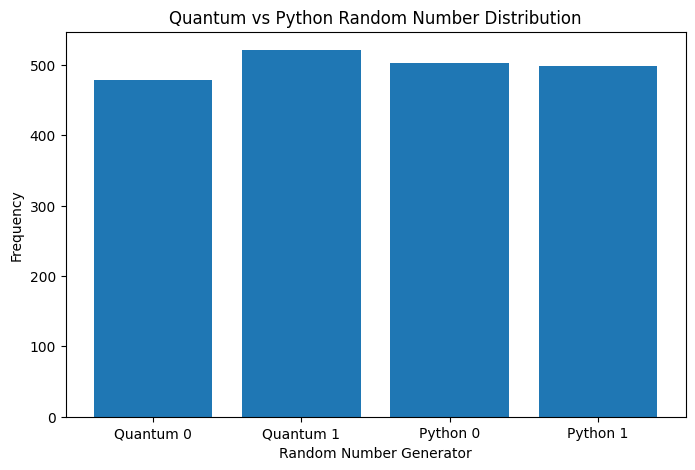

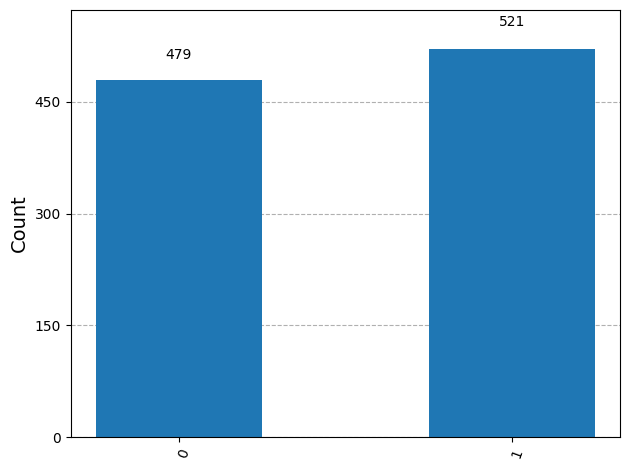

In [14]:
# Compare both generators using a bar graph

labels = ["Quantum 0", "Quantum 1", "Python 0", "Python 1"]

values = [
    quantum_zero,
    quantum_one,
    python_zero,
    python_one
]

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.title("Quantum vs Python Random Number Distribution")
plt.xlabel("Random Number Generator")
plt.ylabel("Frequency")

plt.show()

from qiskit.visualization import plot_histogram

plot_histogram(quantum_counts)

## Conclusion

A Quantum Random Number Generator (QRNG) was successfully simulated using qubit superposition. The statistical distribution of quantum-generated bits was compared with Python's pseudo-random generator. Both produced an approximately equal number of 0s and 1s, demonstrating statistically balanced randomness. However, the quantum generator derives randomness from quantum measurement, whereas Python's generator uses deterministic algorithms.